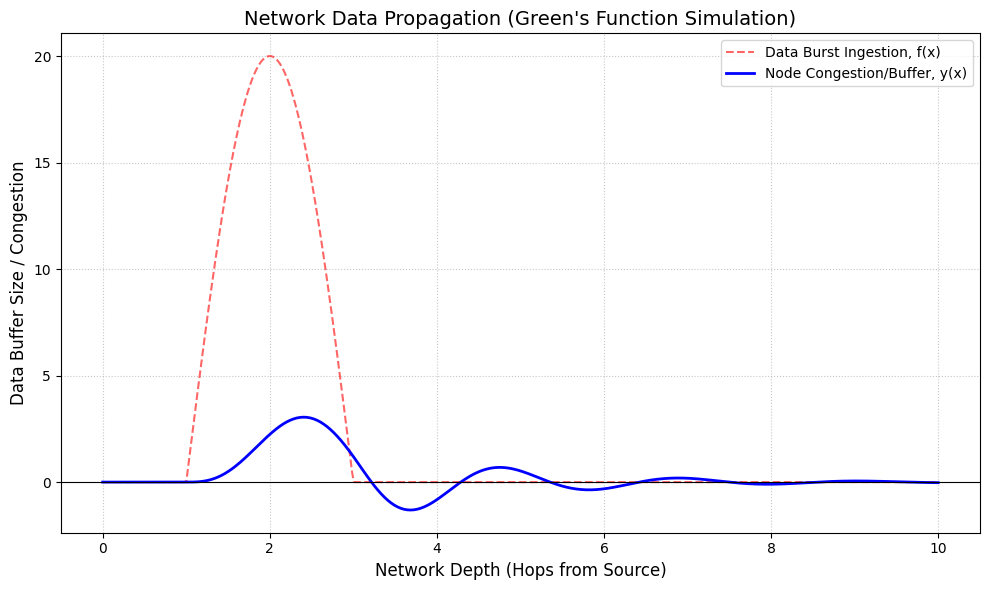

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Latency/Damping factor
zeta = 0.2
# Load balancing frequency
w = 3.0
# Damped frequency
wd = w * np.sqrt(1 - zeta**2)

def forcing_function(t):
    if 1 <= t <= 3:
        return 20.0 * np.sin(np.pi * (t - 1) / 2)
    return 0.0

def greens_function(x, t):
    if x < t:
        return 0.0
    return (1 / wd) * np.exp(-zeta * w * (x - t)) * np.sin(wd * (x - t))

def integrand(t, x):
    return greens_function(x, t) * forcing_function(t)

def compute_propagation(x_nodes):
    y_p = np.zeros_like(x_nodes)
    for i, x in enumerate(x_nodes):
        # Integrate from 0 to x using SciPy's quadrature
        result, _ = quad(integrand, 0, x, args=(x,), limit=100)
        y_p[i] = result
    return y_p

# Define the network topology
nodes = np.linspace(0, 10, 500)

# Compute the network response
data_accumulation = compute_propagation(nodes)

plt.figure(figsize=(10, 6))

# Plot the forcing function (Data Ingestion)
burst_signal = [forcing_function(x) for x in nodes]
plt.plot(nodes, burst_signal, 'r--', alpha=0.6, label='Data Burst Ingestion, f(x)')

# Plot the network response (Data Propagation/Congestion)
plt.plot(nodes, data_accumulation, 'b-', linewidth=2, label='Node Congestion/Buffer, y(x)')

plt.title("Network Data Propagation (Green's Function Simulation)", fontsize=14)
plt.xlabel("Network Depth (Hops from Source)", fontsize=12)
plt.ylabel("Data Buffer Size / Congestion", fontsize=12)
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()